# Predictive Maintenance Analysis using Machine Sensor Data

**Prepared by:** Vyshakh S

**Date:** August 2026

## Introduction

In modern manufacturing, unplanned machine downtime is one of the most costly problems a factory can face — halting production, delaying orders, and driving up repair costs. Traditionally, maintenance is either reactive (fixing machines after they break) or scheduled at fixed intervals regardless of actual machine condition, both of which are inefficient and expensive.

Predictive Maintenance is an approach that uses real-time sensor data — such as temperature, rotational speed, torque, and tool wear — to detect early warning signs of failure before a breakdown occurs. This allows maintenance teams to act proactively, reducing downtime, saving costs, and extending the working life of machinery.

This project analyzes sensor and operational data from industrial milling machines to explore the conditions and patterns that lead to failure, laying the groundwork for a predictive maintenance strategy.

## Objective

To perform exploratory data analysis (EDA) on machine sensor data in order to identify which conditions and sensor readings are most strongly associated with machine failure, and to derive insights that could support a predictive maintenance approach in a manufacturing environment.

## Dataset

- **Source:** AI4I Predictive Maintenance Dataset, UCI Machine Learning Repository
- **Records:** 10,000
- **Features:** 14 (mix of numerical and categorical)
- **Link:** https://archive.ics.uci.edu/dataset/601/ai4i+2020+predictive+maintenance+dataset

## Tools & Libraries Used

- **Python** — core programming language
- **Pandas** — data loading, cleaning, and manipulation
- **NumPy** — numerical computations
- **Matplotlib / Seaborn** — data visualization

## Project Workflow

1. Data Loading and Initial Overview
2. Data Cleaning & Pre-processing
3. Exploratory Data Analysis (EDA)
4. Visualizations
5. Key Insights & Conclusion

## 1. Data Loading and Initial Overview

In this section, we import the required Python libraries and load the dataset into a 
Pandas DataFrame. We then perform an initial inspection to understand the structure of 
the data — checking the number of rows and columns, data types, and basic summary 
statistics before proceeding to cleaning and analysis.

In [1]:
# Data manipulation
import pandas as pd
import numpy as np


# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

In [41]:
df = pd.read_csv(r"C:\Users\vaish\Documents\DATA ANALYTICS\ASSIGNMENTS\FINAL PROJECT\Predictive Maintenance.csv")
df

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,M24855,M,298.8,308.4,1604,29.5,14,0,0,0,0,0,0
9996,9997,H39410,H,298.9,308.4,1632,31.8,17,0,0,0,0,0,0
9997,9998,M24857,M,299.0,308.6,1645,33.4,22,0,0,0,0,0,0
9998,9999,H39412,H,299.0,308.7,1408,48.5,25,0,0,0,0,0,0


In [42]:
print('Shape:',df.shape)
df.info()


Shape: (10000, 14)
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  str    
 2   Type                     10000 non-null  str    
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), 

In [43]:
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [44]:
df.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


## 2. Data Cleaning & Pre-processing

In this section, we check for missing values, duplicates, and incorrect data types, 
and prepare the dataset for analysis by creating any necessary derived columns.

### 2.1 Checking for Missing Values and Duplicates

In [45]:
print('Missing values per column:')
print(df.isnull().sum())

print('Number of duplicate rows:',df.duplicated().sum())

Missing values per column:
UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64
Number of duplicate rows: 0


**Observation:** No missing values or duplicate rows were found in the dataset.

### 2.2 Cleaning Column Names

In [46]:
df.columns

Index(['UDI', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF',
       'RNF'],
      dtype='str')

In [47]:
df.columns = df.columns.str.replace('[','',regex=False).str.replace(']','',regex=False).str.replace(' ','_').str.replace('temperature','Temp').str.strip()
df.columns

Index(['UDI', 'Product_ID', 'Type', 'Air_Temp_K', 'Process_Temp_K',
       'Rotational_speed_rpm', 'Torque_Nm', 'Tool_wear_min', 'Machine_failure',
       'TWF', 'HDF', 'PWF', 'OSF', 'RNF'],
      dtype='str')

**Observation:** No missing values or duplicate rows were found in the dataset. Column names were cleaned (removed brackets, standardized spacing) for easier reference in code.

### 2.3 Feature Engineering: Derived Columns

In [48]:
df['Temp_Diff_K'] = df['Process_Temp_K']-df['Air_Temp_K']
df[['Air_Temp_K','Process_Temp_K','Temp_Diff_K']].head()

,Air_Temp_K,Process_Temp_K,Temp_Diff_K
0,298.1,308.6,10.5
1,298.2,308.7,10.5
2,298.1,308.5,10.4
3,298.2,308.6,10.4
4,298.2,308.7,10.5


In [49]:
#Power(Watts) = Torque(Nm) x Angular velocity(rad/s)
#Angular velocity = Rotational Speed x (2*pi/60)

df['Power_W'] = df['Torque_Nm'] * df['Rotational_speed_rpm'] * (2 * np.pi / 60)
df[['Torque_Nm', 'Rotational_speed_rpm', 'Power_W']].head()

,Torque_Nm,Rotational_speed_rpm,Power_W
0,42.8,1551,6951.590560
1,46.3,1408,6826.722724
2,49.4,1498,7749.387543
3,39.5,1433,5927.504659
4,40.0,1408,5897.816608


**Observation:** The derived column Temp_Diff_K ranges narrowly between 7.6K and 12.1K, 
useful for identifying heat dissipation issues. Power_W ranges from approximately 
1,148W to 10,470W, capturing the mechanical power output of each machine — both 
features will help identify patterns related to specific failure types later in the analysis.

### 2.4 Saving the Cleaned Dataset

After cleaning, we save the processed dataset as a new CSV file. 
This cleaned file will be used for all further analysis, keeping the original raw data 
untouched for reference.

In [54]:
df.to_csv('Predictive Maintenance_cleaned.csv',index = False)
print("\nCleaned dataset saved as 'Predictive Maintenance_cleaned.csv'")


Cleaned dataset saved as 'Predictive Maintenance_cleaned.csv'


### Loading the Cleaned Dataset for Analysis

In [2]:
df = pd.read_csv(r'Predictive Maintenance_cleaned.csv')
df.head()

,UDI,Product_ID,Type,Air_Temp_K,Process_Temp_K,Rotational_speed_rpm,Torque_Nm,Tool_wear_min,Machine_failure,TWF,HDF,PWF,OSF,RNF,Temp_Diff_K,Power_W
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0,10.5,6951.590560
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0,10.5,6826.722724
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0,10.4,7749.387543
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0,10.4,5927.504659
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0,10.5,5897.816608


## 3. Exploratory Data Analysis (EDA)

In this section, we explore the dataset in depth to uncover patterns, relationships, 
and trends related to machine failure. The analysis is structured into three parts:

- **Univariate Analysis** — examining individual variables (categorical and numerical) 
  to understand their distribution
- **Bivariate Analysis** — examining relationships between two variables, particularly 
  how sensor readings relate to machine failure
- **Multivariate Analysis** — examining relationships across multiple variables 
  simultaneously, including correlation analysis

Insights from this section will guide the visualizations and final recommendations 
presented later in the notebook.

## 3.1 Univariate Analysis — Categorical Variables

We begin by examining the distribution of our key categorical variables: Machine_failure 
(target variable) and Type (product quality variant). This helps us understand the 
overall class balance and category proportions before deeper analysis.

In [56]:
print('Machine Failure Counts:')
print(df['Machine_failure'].value_counts())
print('\nFailure Rate:{:.2f}%'.format(df['Machine_failure'].mean()*100))
print('\nType Distribution:')
print(df['Type'].value_counts())

Machine Failure Counts:
Machine_failure
0    9661
1     339
Name: count, dtype: int64

Failure Rate:3.39%

Type Distribution:
Type
L    6000
M    2997
H    1003
Name: count, dtype: int64


**Observation:** The dataset is highly imbalanced — only 3.39% of machines experienced 
failure. This is typical for real-world industrial failure data, where breakdowns are 
rare events. Type L machines make up the majority of the dataset (60%), followed by 
Type M (30%) and Type H (10%).

## 3.2 Univariate Analysis — Numerical Variables (Summary Statistics)

Next, we review summary statistics (mean, standard deviation, min, max, and quartiles) 
for all numerical sensor features. This gives us an initial sense of typical values, 
spread, and potential outliers.

In [57]:
Numerical_columns = ['Air_Temp_K', 'Process_Temp_K',
       'Rotational_speed_rpm', 'Torque_Nm', 'Tool_wear_min',
                     'Temp_Diff_K', 'Power_W']
df[Numerical_columns].describe()

,Air_Temp_K,Process_Temp_K,Rotational_speed_rpm,Torque_Nm,Tool_wear_min,Temp_Diff_K,Power_W
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,300.004930,310.005560,1538.776100,39.986910,107.951000,10.000630,6279.744953
std,2.000259,1.483734,179.284096,9.968934,63.654147,1.001094,1067.418295
min,295.300000,305.700000,1168.000000,3.800000,0.000000,7.600000,1148.440610
25%,298.300000,308.800000,1423.000000,33.200000,53.000000,9.300000,5561.184484
50%,300.100000,310.100000,1503.000000,40.100000,108.000000,9.800000,6271.027344
75%,301.500000,311.100000,1612.000000,46.800000,162.000000,11.000000,7003.002724
max,304.500000,313.800000,2886.000000,76.600000,253.000000,12.100000,10469.923005


**Observation:** Rotational speed shows a noticeable right-skew (75th percentile = 1612 
rpm vs max = 2886 rpm), suggesting some outlier high-speed readings. Power_W and 
Temp_Diff_K, our derived features, show reasonable spread and will be useful for 
analyzing failure patterns.

### 3.3 Univariate Analysis — Distribution Plots (Histograms)

We visualize the distribution of each numerical feature using histograms to understand 
their shape (normal, skewed, or bimodal) and confirm patterns suggested by the summary 
statistics above.

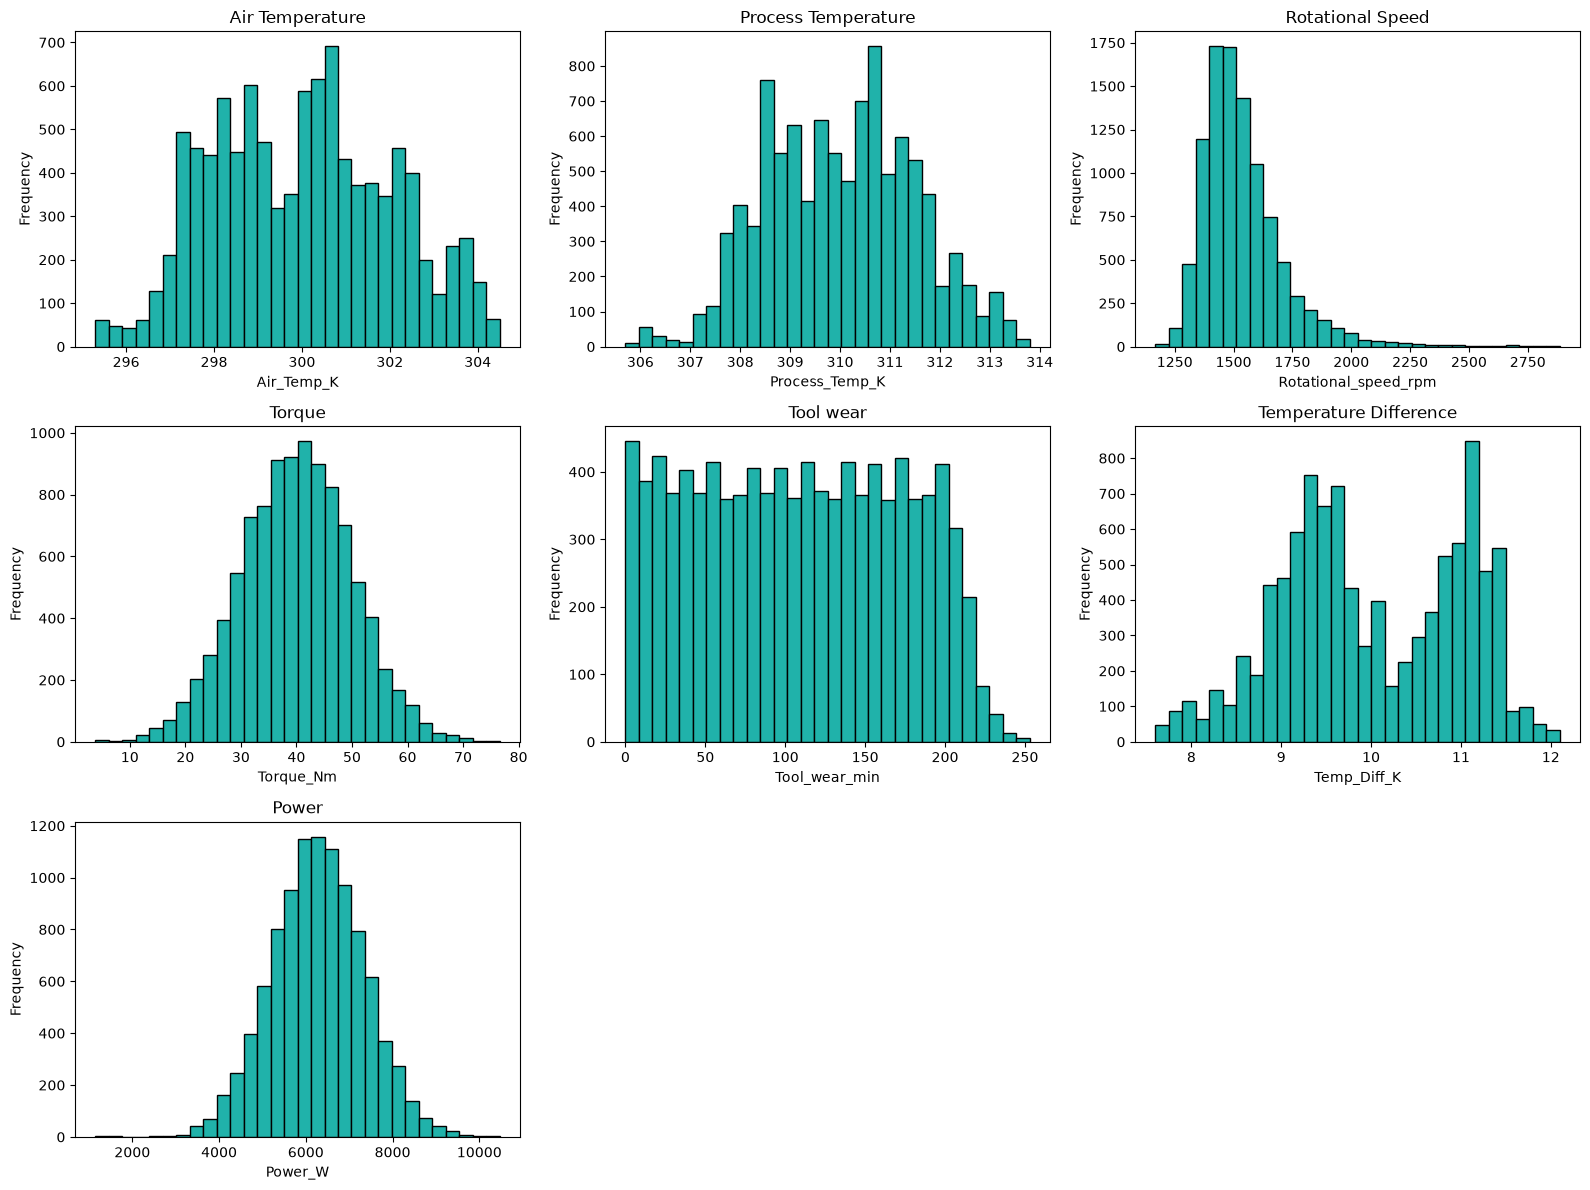

In [58]:
plt.figure(figsize = (16,12))

plt.subplot(3,3,1)
plt.hist(df['Air_Temp_K'],bins = 30,color = '#20B2AA',edgecolor = 'black')
plt.title('Air Temperature')
plt.xlabel('Air_Temp_K')
plt.ylabel('Frequency')

plt.subplot(3,3,2)
plt.hist(df['Process_Temp_K'],bins = 30,color = '#20B2AA',edgecolor = 'black')
plt.title('Process Temperature')
plt.xlabel('Process_Temp_K')
plt.ylabel('Frequency')

plt.subplot(3,3,3)
plt.hist(df['Rotational_speed_rpm'],bins = 30,color = '#20B2AA',edgecolor = 'black')
plt.title('Rotational Speed')
plt.xlabel('Rotational_speed_rpm')
plt.ylabel('Frequency')

plt.subplot(3,3,4)
plt.hist(df['Torque_Nm'],bins = 30,color = '#20B2AA',edgecolor = 'black')
plt.title('Torque')
plt.xlabel('Torque_Nm')
plt.ylabel('Frequency')

plt.subplot(3,3,5)
plt.hist(df['Tool_wear_min'],bins = 30,color = '#20B2AA',edgecolor = 'black')
plt.title('Tool wear')
plt.xlabel('Tool_wear_min')
plt.ylabel('Frequency')

plt.subplot(3,3,6)
plt.hist(df['Temp_Diff_K'],bins = 30,color = '#20B2AA',edgecolor = 'black')
plt.title('Temperature Difference')
plt.xlabel('Temp_Diff_K')
plt.ylabel('Frequency')

plt.subplot(3,3,7)
plt.hist(df['Power_W'],bins = 30,color = '#20B2AA',edgecolor = 'black')
plt.title('Power')
plt.xlabel('Power_W')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

**Observations:**
- Rotational speed is right-skewed, with a long tail of high-speed outliers.
- Tool wear is uniformly distributed (0-250 min), suggesting even sampling across wear stages.
- Temperature difference shows a bimodal pattern (two peaks around 9K and 11K), possibly 
  indicating two distinct machine operating conditions.
- Torque, Air Temp, and Power follow roughly normal (bell-shaped) distributions.

### 3.4 Machine Failure Distribution (Bar Chart)

This bar chart visualizes the count of machines that failed versus those that did not, 
highlighting the class imbalance noted earlier in Section 3.1.

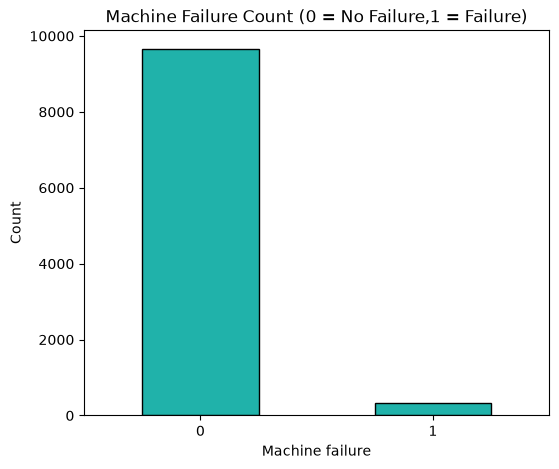

In [61]:
plt.figure(figsize = (6,5))
df['Machine_failure'].value_counts().plot(kind='bar',color = '#20B2AA',edgecolor = 'black')
plt.title('Machine Failure Count (0 = No Failure,1 = Failure)')
plt.xlabel('Machine failure')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()


**Observation:** The dataset shows a clear class imbalance, with 9,661 machines (96.6%) 
showing no failure and only 339 machines (3.4%) experiencing failure. This imbalance 
will be an important consideration when interpreting patterns in the remaining analysis.

### 3.5 Type Distribution (Pie Chart)

This shows the proportion of machines across the three product quality variants — 
Low (L), Medium (M), and High (H). A pie chart is used here since we're showing parts 
of a whole (percentage share), rather than comparing separate counts.

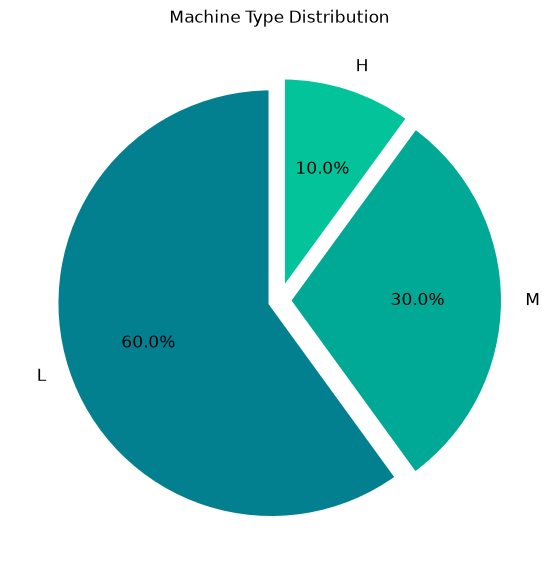

In [4]:
type_counts = df['Type'].value_counts()

plt.figure(figsize=(7,7))
plt.pie(type_counts, labels=type_counts.index, autopct='%1.1f%%', startangle=90,
        colors=['#028090', '#00A896', '#02C39A'],
        explode=(0.04, 0.04, 0.04),
        wedgeprops={'edgecolor': 'white', 'linewidth': 4},
        textprops={'fontsize': 12})
plt.title('Machine Type Distribution')
plt.show()

**Observation:** Type L (Low) machines make up the majority of the dataset at 60% 
(6,000 units), followed by Type M (Medium) at 30% (2,997 units), and Type H (High) 
at 10% (1,003 units).

### 3.6 Failure Rate by Machine Type (Bar Chart)

Having seen the individual distributions of Type and Machine_failure, we now examine 
whether machine type has any relationship with failure rate — comparing a categorical 
variable against our target variable.

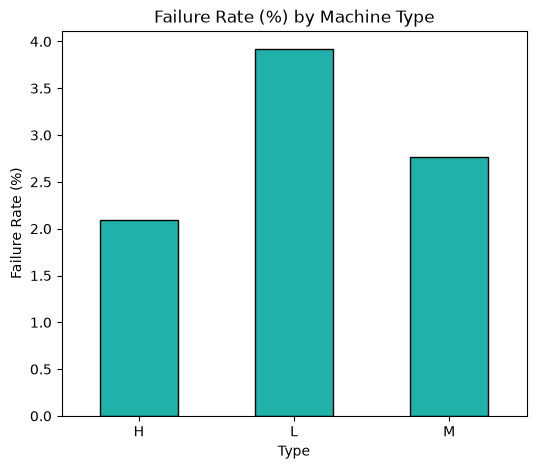

Type
H    2.093719
L    3.916667
M    2.769436
Name: Machine_failure, dtype: float64


In [70]:
failure_by_type = df.groupby('Type')['Machine_failure'].mean()*100

plt.figure(figsize=(6,5))
failure_by_type.plot(kind='bar',color = '#20B2AA',edgecolor = 'black')
plt.title('Failure Rate (%) by Machine Type')
plt.xlabel('Type')
plt.ylabel('Failure Rate (%)')
plt.xticks(rotation=0)
plt.show()

print(failure_by_type)

**Observation:** Failure rate clearly decreases as product quality type increases — 
Type L (Low) machines fail at 3.92%, nearly double the rate of Type H (High) machines 
at 2.09%. Type M (Medium) falls in between at 2.77%. This suggests that machine/component 
quality grade is a meaningful factor in failure risk, consistent with the expectation 
that higher-quality components have better manufacturing tolerances and durability.

### 3.7 Torque vs Machine Failure (Box Plot)

Using a box plot, we compare torque values between machines that failed and those that 
did not, to examine whether torque levels are associated with failure risk.

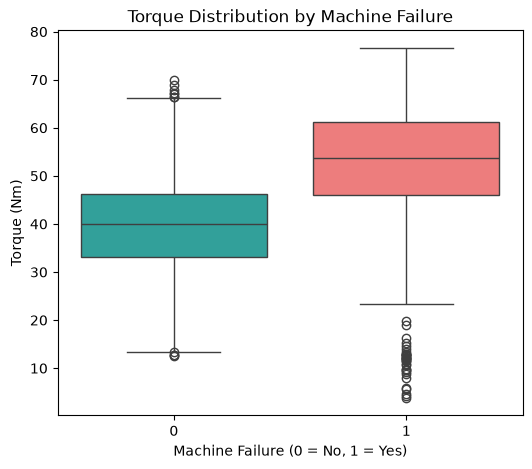

In [72]:
plt.figure(figsize=(6,5))
sns.boxplot(x='Machine_failure', y='Torque_Nm', hue='Machine_failure', 
            data=df, palette=['#20B2AA', '#FF6B6B'], legend=False)
plt.title('Torque Distribution by Machine Failure')
plt.xlabel('Machine Failure (0 = No, 1 = Yes)')
plt.ylabel('Torque (Nm)')
plt.show()

**Observation:** Machines that experienced failure (1) show noticeably higher torque 
values compared to machines that did not fail (0). This suggests that higher torque 
places greater mechanical stress on components, increasing the likelihood of failure — 
consistent with the "Overstrain Failure" (OSF) category in the dataset, which occurs 
when torque and tool wear combine to exceed a machine's strain thres

### 3.8 Tool Wear vs Machine Failure (Box Plot)

We examine whether tool wear (measured in minutes) differs between machines that failed 
and those that did not, using the same box plot comparison approach.

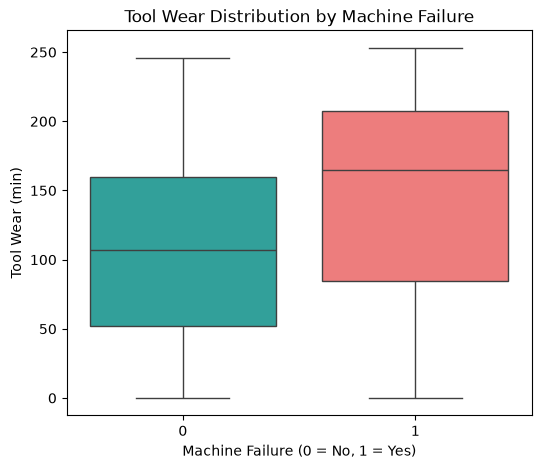

In [73]:
plt.figure(figsize=(6,5))
sns.boxplot(x='Machine_failure', y='Tool_wear_min', hue='Machine_failure', 
            data=df, palette=['#20B2AA', '#FF6B6B'], legend=False)
plt.title('Tool Wear Distribution by Machine Failure')
plt.xlabel('Machine Failure (0 = No, 1 = Yes)')
plt.ylabel('Tool Wear (min)')
plt.show()

**Observation:** Machines that failed (1) show higher tool wear values compared to 
machines that did not fail (0). This aligns with expected mechanical behavior — as 
cutting tools wear down over time, they generate more friction, heat, and mechanical 
stress, increasing the likelihood of failure. This supports the "Tool Wear Failure" 
(TWF) category present in the dataset.

### 3.9 Temperature Difference vs Machine Failure (Box Plot)

We examine whether our derived feature, Temp_Diff_K (the gap between process and air 
temperature), differs between failed and non-failed machines. A smaller gap may indicate 
poor heat dissipation, a known failure mechanism (Heat Dissipation Failure).

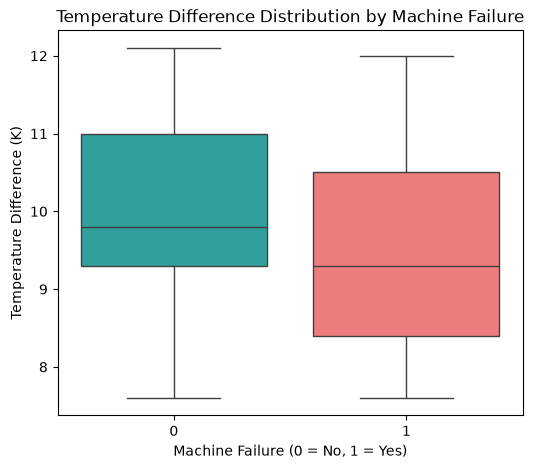

In [74]:
plt.figure(figsize=(6,5))
sns.boxplot(x='Machine_failure', y='Temp_Diff_K', hue='Machine_failure', 
            data=df, palette=['#20B2AA', '#FF6B6B'], legend=False)
plt.title('Temperature Difference Distribution by Machine Failure')
plt.xlabel('Machine Failure (0 = No, 1 = Yes)')
plt.ylabel('Temperature Difference (K)')
plt.show()

**Observation:** Machines that failed (1) show a smaller temperature difference 
(Temp_Diff_K) compared to machines that did not fail (0). This supports the hypothesis 
that poor heat dissipation — where process temperature stays too close to air 
temperature — is associated with failure, consistent with the "Heat Dissipation 
Failure" (HDF) category in the dataset.

### 3.10 Torque vs Rotational Speed (Scatter Plot)

We use a scatter plot to examine the relationship between torque and rotational speed, 
colored by failure status, to see if failures cluster in specific regions of this 
relationship.

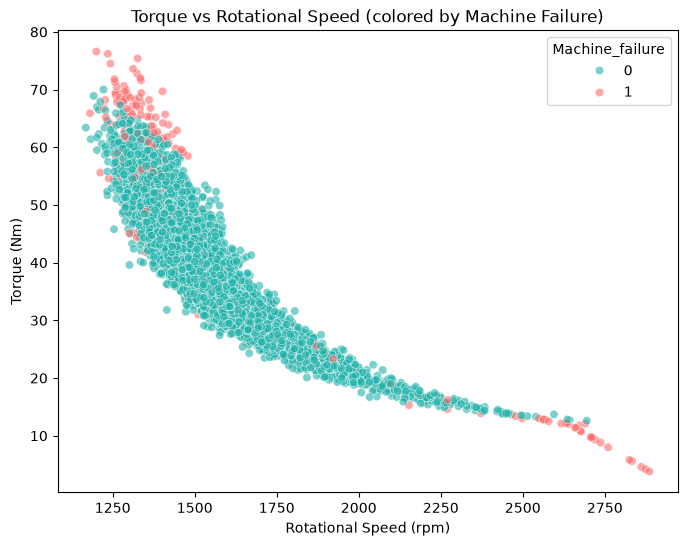

In [77]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='Rotational_speed_rpm', y='Torque_Nm', hue='Machine_failure', 
                 data=df, palette=['#20B2AA', '#FF6B6B'], alpha=0.6)
plt.title('Torque vs Rotational Speed (colored by Machine Failure)')
plt.xlabel('Rotational Speed (rpm)')
plt.ylabel('Torque (Nm)')
plt.show()

**Observation:** The scatter plot reveals two distinct clusters of machine failure:
1. High torque (50-70+ Nm) combined with low-to-moderate rotational speed (1400-1800 rpm) 
   — likely representing Overstrain Failures (OSF), where excessive torque places 
   mechanical stress beyond safe limits.
2. High rotational speed (2500-2800 rpm) combined with low torque — likely representing 
   Power Failures (PWF), where excessive speed alone leads to instability or breakdown.

This confirms that machine failure is not driven by a single variable in isolation, but 
by specific combinations of torque and speed — reinforcing the importance of our derived 
Power_W feature, which captures this combined relationship.

### 3.11 Correlation Heatmap (Multivariate Analysis)

We use a correlation heatmap to examine relationships between all numerical variables 
simultaneously, helping identify which features move together and which are most 
strongly associated with machine failure.

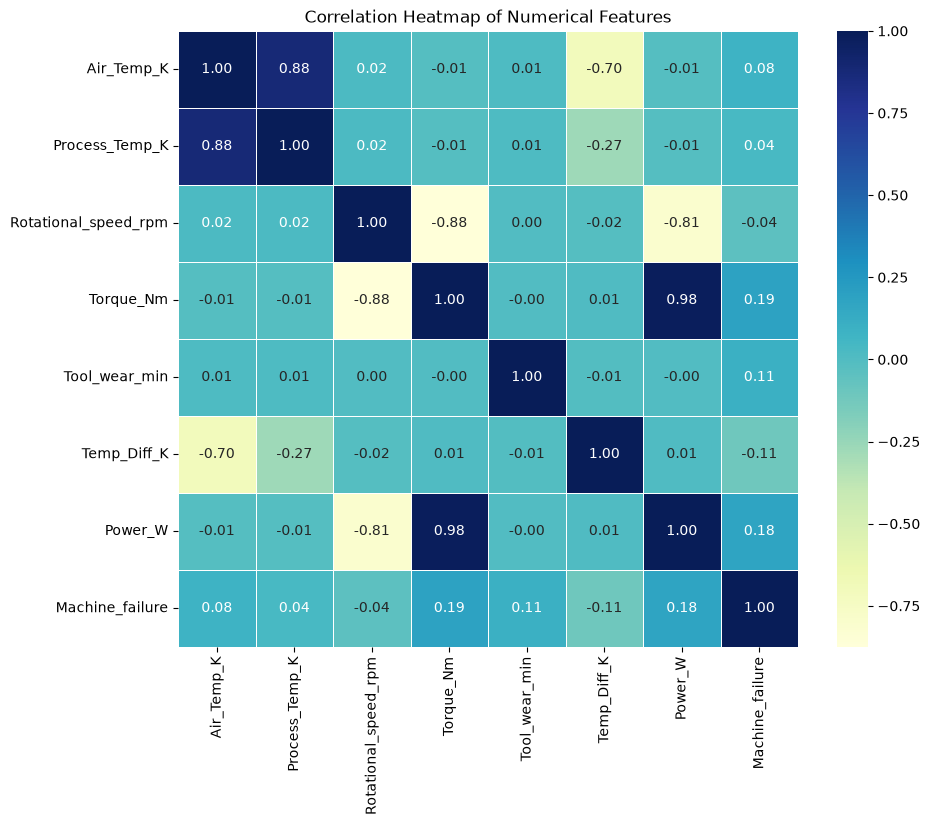

In [79]:
numerical_cols = ['Air_Temp_K', 'Process_Temp_K', 'Rotational_speed_rpm', 
                   'Torque_Nm', 'Tool_wear_min', 'Temp_Diff_K', 'Power_W']

plt.figure(figsize=(10,8))
correlation_matrix = df[numerical_cols + ['Machine_failure']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='YlGnBu', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

**Observation:** The correlation heatmap confirms several relationships:
- Torque_Nm and Power_W are almost perfectly correlated (0.98), as expected since 
  Power was mathematically derived from Torque.
- Rotational_speed_rpm and Torque_Nm show a strong negative correlation (-0.88), 
  explaining the two separate failure clusters seen in the earlier scatter plot.
- Among individual features, Torque_Nm (0.19) and Power_W (0.18) show the strongest 
  positive correlation with Machine_failure, while Temp_Diff_K (-0.11) shows a 
  negative correlation — confirming patterns identified in the earlier box plots.
- No single variable shows a very high correlation with failure alone, suggesting 
  that

### 3.12 Failure Type Breakdown (Bar Chart)

We examine the frequency of each specific failure type to understand which mechanical 
failure modes are most common in this dataset.

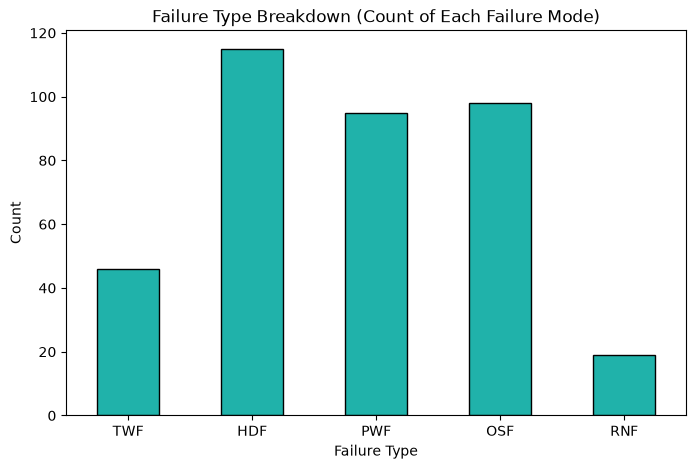

TWF     46
HDF    115
PWF     95
OSF     98
RNF     19
dtype: int64


In [80]:
failure_types = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']
failure_counts = df[failure_types].sum()

plt.figure(figsize=(8,5))
failure_counts.plot(kind='bar', color='#20B2AA', edgecolor='black')
plt.title('Failure Type Breakdown (Count of Each Failure Mode)')
plt.xlabel('Failure Type')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

print(failure_counts)

**Observation:** Heat Dissipation Failure (HDF) is the most common failure mode (115 
occurrences), followed closely by Overstrain Failure (OSF, 98) and Power Failure 
(PWF, 95). Tool Wear Failure (TWF) occurs less frequently (46), and Random Failure 
(RNF) is the rarest (19) — consistent with its definition as an unpredictable failure 
not linked to any specific operating condition. This suggests that heat management and 
mechanical strain are the leading contributors to machine failure in this dataset, and 
would be the most impactful areas for a plant to focus predictive maintenance efforts on.

### 3.13 Power Distribution by Failure Type

We compare Power_W across machines that experienced no failure versus those affected 
by each specific failure type, to see which failure modes are most closely linked to 
power output.

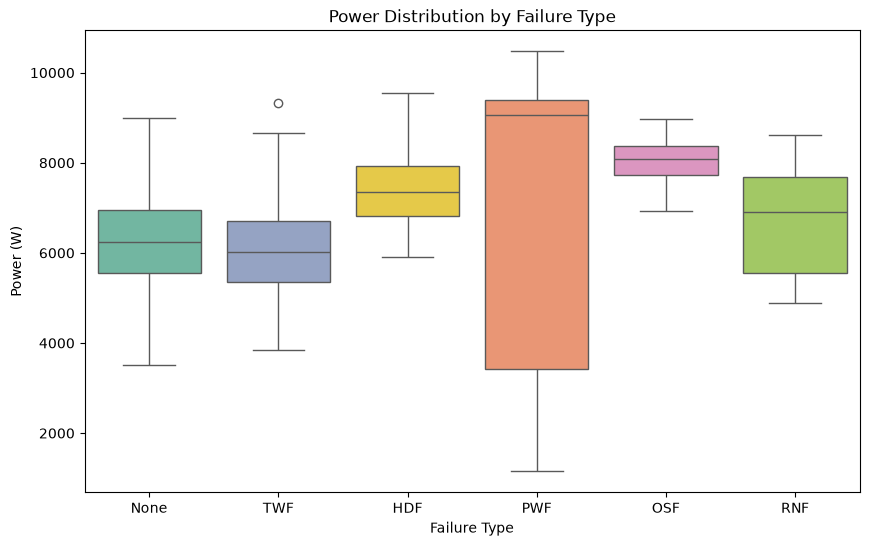

In [81]:
# Create a single column showing which failure type occurred (or 'None')
def get_failure_type(row):
    if row['TWF'] == 1: return 'TWF'
    elif row['HDF'] == 1: return 'HDF'
    elif row['PWF'] == 1: return 'PWF'
    elif row['OSF'] == 1: return 'OSF'
    elif row['RNF'] == 1: return 'RNF'
    else: return 'None'

df['Failure_Type'] = df.apply(get_failure_type, axis=1)

plt.figure(figsize=(10,6))
sns.boxplot(x='Failure_Type', y='Power_W', hue='Failure_Type', data=df, 
            palette='Set2', legend=False, 
            order=['None', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF'])
plt.title('Power Distribution by Failure Type')
plt.xlabel('Failure Type')
plt.ylabel('Power (W)')
plt.show()

**Observation:** Power Failure (PWF) shows by far the widest spread in Power_W values 
(ranging from roughly 1,500W to 9,600W), consistent with its definition as a failure 
that occurs at both power extremes — insufficient power to perform the operation, or 
excessive power straining the machine. Other failure types (HDF, OSF, TWF, RNF) show 
power distributions closer to the "None" (no failure) baseline, suggesting these 
failure modes are driven more specifically by their respective root causes (heat, 
torque/wear) rather than power extremes alone.

### Summary of EDA Findings

Across the univariate, bivariate, and multivariate analysis in this section, several 
consistent patterns emerged: machine failure is associated with higher torque and 
power, reduced temperature difference (poor heat dissipation), and lower product 
quality grade (Type L). Heat Dissipation Failure emerged as the most frequent failure 
mode, while the scatter plot analysis showed that failures cluster around specific 
combinations of torque and rotational speed rather than any single variable in 
isolation. These findings form the basis for the key insights and recommendations 
presented in the following section.

## 4. Key Insights & Conclusion

### Executive Summary

This analysis of 10,000 industrial machines found that failure is driven by specific 
combinations of mechanical stress and heat conditions, rather than any single sensor 
reading. Torque and Power emerged as the strongest individual predictors, while Heat 
Dissipation Failure was the most common failure mode overall — directly validated by 
our engineered Temp_Diff_K feature. Machine build quality also played a measurable 
role, with lower-grade machines failing at nearly twice the rate of high-grade ones. 
Together, these findings point toward a clear, actionable path: prioritizing heat and 
torque/power monitoring would address the majority of failure risk in this dataset.

### Key Insights

1. **Class Imbalance:** Only 3.39% of machines (339 out of 10,000) experienced failure, 
   reflecting the real-world rarity of industrial breakdowns. This imbalance is an 
   important consideration for any future predictive modeling on this data.

2. **Machine Type Affects Failure Risk:** Type L (Low quality) machines fail at 3.92%, 
   nearly double the rate of Type H (High quality) machines at 2.09%. This suggests 
   component/build quality is a meaningful factor in reliability.

3. **Torque and Power Are Key Failure Drivers:** Machines that failed showed noticeably 
   higher torque and power values compared to those that didn't. Torque_Nm (0.19) and 
   Power_W (0.18) had the strongest correlations with Machine_failure among all 
   numerical features.

4. **Heat Dissipation Is the Leading Failure Mode:** Heat Dissipation Failure (HDF) was 
   the most common failure type (115 occurrences), and machines that failed showed a 
   smaller Temp_Diff_K (process-air temperature gap) — confirming that poor heat 
   dissipation is strongly linked to breakdown risk.

5. **Failures Cluster Around Specific Operating Conditions:** The scatter plot of Torque 
   vs Rotational Speed revealed two distinct failure clusters — high torque at low 
   speed, and high speed at low torque — showing that failure is driven by specific 
   combinations of conditions rather than any single variable acting alone.

### Recommendations

- Prioritize monitoring and maintenance around **heat dissipation systems**, since HDF 
  is the most frequent failure mode.
- Implement **torque and power threshold alerts**, since these showed the strongest 
  individual correlation with failure.
- Consider **quality-grade-specific maintenance schedules**, since Type L machines fail 
  nearly twice as often as Type H machines.
- Future work could involve building a **classification model** (e.g., Random Forest) 
  using these engineered features (Temp_Diff_K, Power_W) to predict failure in advance, 
  enabling a shift from reactive to predictive maintenance.

### Suggested Next Steps for Implementation

- Set an alert threshold when Torque_Nm exceeds approximately 45-50 Nm (values where 
  failure risk visibly increases in the box plot analysis) combined with Rotational 
  Speed outside the 1400-1800 rpm typical operating band.
- Flag machines when Temp_Diff_K drops below approximately 9K, as this range showed 
  a higher concentration of Heat Dissipation Failures.
- Schedule more frequent inspections for Type L machines, given their meaningfully 
  higher failure rate compared to Type H.

### Conclusion

This analysis of the AI4I Predictive Maintenance dataset revealed that machine 
failure is not driven by any single sensor reading in isolation, but by specific 
combinations of torque, power, temperature difference, and mechanical quality grade. 
By engineering features grounded in mechanical engineering principles — particularly 
Power_W (P = τω) and Temp_Diff_K (heat dissipation indicator) — this project 
demonstrated how domain knowledge can meaningfully strengthen a data analytics workflow, 
uncovering patterns that support a more proactive, cost-effective approach to industrial 
maintenance.